In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")


In [27]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nChurn distribution:")
print(df['Churn'].value_counts())


Shape: (7043, 21)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

In [29]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')


In [30]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())


In [31]:
df=df.drop('customerID',axis=1)

In [32]:
categorical_cols=df.select_dtypes(include=['object']).columns
df_encoded=pd.get_dummies(df,columns=categorical_cols,drop_first=True)

In [33]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [37]:
X=df_encoded.drop("Churn_Yes",axis=1)

y=df_encoded["Churn_Yes"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [38]:
print(X.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [39]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [40]:
logreg=LogisticRegression(max_iter=1000)
rf=RandomForestClassifier(random_state=42)
logreg.fit(X_train_scaled,y_train)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
logreg_cv=cross_val_score(logreg,X_train_scaled,y_train,cv=5,scoring='accuracy')
rf_cv=cross_val_score(rf,X_train, y_train,cv=5,scoring='accuracy')
print("Logistic Regression CV mean accuracy:",logreg_cv.mean())
print("Random Forest CV mean accuracy:",rf_cv.mean())


Logistic Regression CV mean accuracy: 0.8042220579636595
Random Forest CV mean accuracy: 0.7882484030758029


In [42]:
logreg_params={
    'C':[0.01, 0.1, 1, 10],
    'penalty':['l2']
}

logreg_grid=GridSearchCV(
    LogisticRegression(max_iter=1000),
    logreg_params,
    cv=5,
    scoring='accuracy'
)

logreg_grid.fit(X_train_scaled,y_train)


,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [49]:
print(logreg_grid.best_params_)
print(logreg_grid.best_score_)

{'C': 10, 'penalty': 'l2'}
0.8047544448314502


In [43]:
rf_params = {
    'n_estimators':[100, 200],
    'max_depth':[10, 20, None],
    'min_samples_split':[2, 5, 10]
}

rf_grid=GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy'
)

rf_grid.fit(X_train,y_train)


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [50]:
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
0.7985418462697458


In [44]:
print("Best Logistic Regression:",logreg_grid.best_params_)
print("Best Random Forest:", rf_grid.best_params_)

Best Logistic Regression: {'C': 10, 'penalty': 'l2'}
Best Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [45]:
best_logreg_score=logreg_grid.best_score_
best_rf_score=rf_grid.best_score_

if best_rf_score>best_logreg_score:
    best_model=rf_grid.best_estimator_
    model_name="Random Forest"
else:
    best_model=logreg_grid.best_estimator_
    model_name="Logistic Regression"

print("Selected Best Model:",model_name)


Selected Best Model: Logistic Regression


In [46]:
if model_name=="Logistic Regression":
    y_pred=best_model.predict(X_test_scaled)
    y_pred_proba=best_model.predict_proba(X_test_scaled)[:,1]
else:
    y_pred=best_model.predict(X_test)
    y_pred_proba=best_model.predict_proba(X_test)[:,1]

acc=accuracy_score(y_test, y_pred)
prec=precision_score(y_test, y_pred)
rec=recall_score(y_test, y_pred)
f1=f1_score(y_test, y_pred)
roc_auc=roc_auc_score(y_test, y_pred_proba)
cm=confusion_matrix(y_test, y_pred)

print("Accuracy:",acc)
print("Precision:",prec)
print("Recall:",rec)
print("F1-score:",f1)
print("ROC-AUC:",roc_auc)
print("Confusion Matrix:\n",cm)


Accuracy: 0.801277501774308
Precision: 0.6477987421383647
Recall: 0.5508021390374331
F1-score: 0.5953757225433526
ROC-AUC: 0.8408354646206309
Confusion Matrix:
 [[923 112]
 [168 206]]


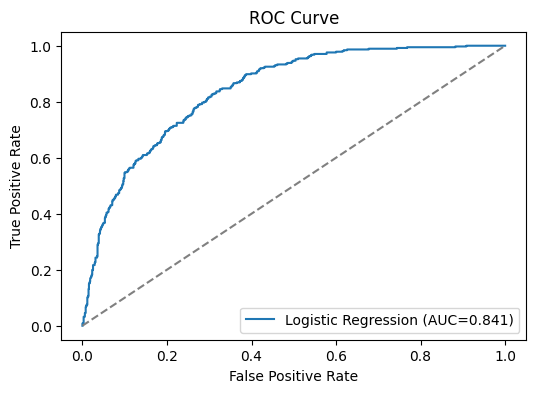

In [47]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,label=f"{model_name} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [48]:
if model_name=="Random Forest":
    importances=best_model.feature_importances_
    indices=np.argsort(importances)[-15:]

    plt.figure(figsize=(8,6))
    plt.barh(range(len(indices)),importances[indices])
    plt.yticks(range(len(indices)),X.columns[indices])
    plt.title("Top 15 Feature Importances")
    plt.show()


Logistic Regression
